In [1]:
import random
import numpy as np
from utils import *
from ploting import *

In [2]:
#add class to date 0 = <0.5 and 1 = >=0.5
data = np.random.uniform(0, 1, (100000, 1))
data = np.hstack(((data >= 0.5).astype(int), data))
data = data_to_world(data, 0.2 )
# data to pandas dataframe
import pandas as pd
df = pd.DataFrame(data[:, :-1], columns=["class", "True Value", "Observed Value", "Uncertainty"])

In [20]:
import numpy as np
from math import log

def find_threshold_entropy_uncertain(x, y, m,
                           idx,
                            n_classes, min_leaf, uncertainty_multiplyer):
    """
    Find the threshold for continuous attribute values that maximizes
    information gain.

    Argument min_leaf sets the minimal number of data instances on each side
    of the threshold. If there is no threshold within that limits with positive
    information gain, the function returns (0, 0).

    Args:
        x: attribute values
        y: class values
        idx: arg-sorted indices of x (and y)
        n_classes: the number of classes
        min_leaf: the minimal number of instances on each side of the threshold
        uncertainty_multiplyer: uncertainty multiplyer 

    Returns:
        (highest information gain, the corresponding optimal threshold)
    """
    # print("x = ", list(x))
    # print("y = ", list(y))
    # print("m = ", list(m))
    # print("idx = ", list(idx))
    # print("n_classes = ", n_classes)
    # print("min_leaf = ", min_leaf)
    
    distr = np.zeros(2 * n_classes, dtype=np.uint32)
    offset_distr = np.zeros(2 * n_classes, dtype=np.uint32)
    # i, j
    # entro, class_entro, best_entro
    # p, curr_y
    best_cut = None
    N = idx.shape[0]

    # Initial split (min_leaf on the left)
    if N <= min_leaf:
        return 0, 0
    
    # min_leaf = 1 # we have to check all possoble splits
    
    for i in range(0):  # one will be added in the loop
        distr[n_classes + int(y[idx[i]])] += 1
    for i in range(0, N):
        distr[int(y[idx[i]])] += 1
    
    # print("distr", distr)
    
    # Compute class entropy
    class_entro = N * log(N)
    for j in range(n_classes):
        p = distr[j] + distr[j + n_classes]
        if p:
            class_entro -= p * log(p)
    best_entro = class_entro
    
    # Loop through
    for i in range(0, N - 1):
        curr_y = int(y[idx[i]])
        distr[curr_y] -= 1
        distr[n_classes + curr_y] += 1
        i_offset = 0
        offset = (-m[idx[i]] + m[idx[i+1]]) * uncertainty_multiplyer # correction to the uncertain side
        cut = (x[idx[i]] + x[idx[i+1]]) * 0.5
        if offset < 0:  # glede na to a se offset zveče al zmanša maš 2 variante al se premekne levo al desno nov treshold
            while i + i_offset > 0 and cut + offset < x[idx[i + i_offset]]:
                i_offset -= 1
        if offset > 0:
            while i + i_offset + 1 < N and cut + offset > x[idx[i + i_offset + 1]]:
                i_offset += 1
                
        if i + i_offset < min_leaf - 1 or i + i_offset > N - min_leaf - 1:
            continue
        
        for j in range(0, len(distr)): #coppy distr
            offset_distr[j] = distr[j]
        if i_offset > 0:
            for j in range(1, i_offset+1):
                curr_y = int(y[idx[i + j]])
                offset_distr[curr_y] -= 1
                offset_distr[n_classes + curr_y] += 1
        if i_offset < 0:
            for j in range(i_offset, 0):
                curr_y = int(y[idx[i + j]])
                offset_distr[curr_y] += 1
                offset_distr[n_classes + curr_y] -= 1
        
        if x[idx[i + i_offset]] != x[idx[i + i_offset + 1]]:
            entro = (i + i_offset + 1) * log(i + i_offset + 1) + (N - (i + i_offset) - 1) * log(N - (i + i_offset) - 1)
            for j in range(2 * n_classes):
                if offset_distr[j]:
                    entro -= offset_distr[j] * log(offset_distr[j])
            if entro < best_entro:
                print("cut = ", cut, "offset = ", offset, "i = ", i, "entro = ", entro)
                best_entro = entro
                best_cut = cut + offset
    
    # print(best_cut)
    if best_cut is None:
        return 0, 0
    
    return (class_entro - best_entro) / N / log(2), best_cut


In [4]:
best_score, best_cut = find_threshold_entropy_uncertain(
                    col_x, data.Y, col_m, arginds,
                    len(class_var.values), self.min_samples_leaf, self.uncertainty_multiplier)

NameError: name 'col_x' is not defined

In [5]:
x =  [0.6315830194020284, 0.6005169976989805, 0.685445512338765, 0.6646589970581247, 0.8702451499838711, 0.7900349589151867]
y =  [3.0, 3.0, 3.0, 2.0, 3.0, 3.0]
m =  [0.15964653, 0.000455345, 0.11042741, 0.14302266, 0.006831112, 0.09479967]
idx =  [1, 0, 3, 2, 5, 4]
n_classes =  2
min_leaf =  1
x = np.array(x)
y = np.array(y)
m = np.array(m)
idx = np.array(idx)

find_threshold_entropy_uncertain(x, y, m,
                           idx,
                            n_classes, min_leaf, 0.5)

IndexError: index 5 is out of bounds for axis 0 with size 4

In [14]:
# class	True Value	Observed Value	Uncertainty
# 7	    0.0	0.437883	0.326706	0.111177
# 4	    0.0	0.416072	0.376993	0.039078
# 19	1.0	0.526898	0.423483	0.103415
# 3	    0.0	0.350223	0.536252	0.186030
# 0	    0.0	0.381993	0.545935	0.163942
# 13	1.0	0.683096	0.636537	0.046560
# 18	1.0	0.584060	0.651981	0.067920
# 17	1.0	0.694440	0.757164	0.062724
data = np.array([[0.0, 0.437883, 0.326706, 0.111177],
                 [0.0, 0.416072, 0.376993, 0.039078],
                 [1.0, 0.526898, 0.423483, 0.103415],
                 [0.0, 0.350223, 0.536252, 0.186030],
                 [0.0, 0.381993, 0.545935, 0.163942],
                 [1.0, 0.683096, 0.636537, 0.046560],
                 [1.0, 0.584060, 0.651981, 0.067920],
                 [1.0, 0.694440, 0.757164, 0.062724]])

data = pd.DataFrame(data, columns=["class", "True Value", "Observed Value", "Uncertainty"])
data

,class,True Value,Observed Value,Uncertainty
0,0.0,0.437883,0.326706,0.111177
1,0.0,0.416072,0.376993,0.039078
2,1.0,0.526898,0.423483,0.103415
3,0.0,0.350223,0.536252,0.186030
4,0.0,0.381993,0.545935,0.163942
5,1.0,0.683096,0.636537,0.046560
6,1.0,0.584060,0.651981,0.067920
7,1.0,0.694440,0.757164,0.062724


cut =  0.35184950000000004 offset =  -0.0360495 i =  0 entro =  4.780356732903301
cut =  0.5410934999999999 offset =  -0.011043999999999998 i =  3 entro =  2.5020121176909393
cut =  0.35184950000000004 offset =  0.0 i =  0 entro =  4.780356732903301
cut =  0.400238 offset =  0.0 i =  1 entro =  3.8190850097688775
cut =  0.591236 offset =  0.0 i =  4 entro =  2.5020121176909393


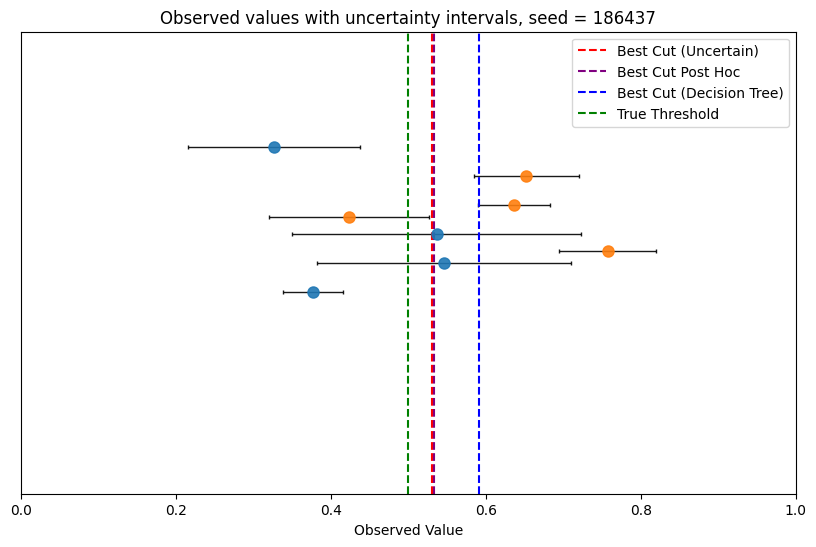

In [25]:
# plot the data
# randomly select 10 points from each class in the data and plot them

# SEED = random.randint(0, 1000000)
# SEED = 186437 # 875877 680648 886904 664990 617159 339127 186437
# random.seed(SEED)

# data = df.groupby("class").apply(lambda x: x.sample(n=10, random_state=SEED)).reset_index(drop=True)

x = data["Observed Value"].values
y = data["class"].values
m = data["Uncertainty"].values
# remove = (x > 0.3) & (x < 0.76) & ~((x > 0.40) & (x < 0.42))

idx = np.argsort(x)
# remove = remove[idx]
# print(remove)
# print(idx[remove])
idx_orig = idx
# x = x[idx[remove]]

# remove index 6 from idx

x = x[idx_orig]
y = y[idx_orig]
m = m[idx_orig]
idx = np.argsort(x)

# x = x.round(3)
# x[idx[9]] += 0.01

_, best_cut_unc = find_threshold_entropy_uncertain(x, y, m,
                           idx,
                            n_classes, min_leaf, 0.5)

_, best_cut_dt = find_threshold_entropy_uncertain(x, y, m * 0,
                           idx,
                            n_classes, min_leaf, 0.5)

closest_idx = np.argsort(np.abs(x - best_cut_dt))[:2]
offset = (-m[closest_idx[0]] + m[closest_idx[1]]) * 0.5
best_cut_post_hoc = best_cut_dt + offset

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Select points closest to best_cut_dt
n_closest = 8
closest_idx = np.argsort(np.abs(x - best_cut_dt))[:n_closest]
closest_mask = np.zeros(len(x), dtype=bool)
closest_mask[closest_idx] = True

# Jitter only the closest points upward by fixed amounts
y_pos = np.zeros(len(x))
fixed_jitter = np.array([0.01, 0.02, 0.015, 0.025, 0.012, 0.018, 0.005, 0.03])  # Fixed jitter values for the closest points
y_pos[closest_idx] = fixed_jitter[:len(closest_idx)]

class_colors = np.where(y == 0, "#1f77b4", "#ff7f0e")
for i, (xi, yi, ui, ci) in enumerate(zip(x, y_pos, m, class_colors)):
    if closest_mask[i]:
        plt.errorbar(
            xi, yi,
            xerr=ui,
            fmt="o",
            markersize=8,
            markerfacecolor=ci,
            markeredgecolor=ci,
            ecolor="black",
            elinewidth=1,
            capsize=1.5,
            capthick=1,
            alpha=0.9
        )
    else:
        plt.plot(xi, 0, "o", markersize=8, color=ci, alpha=0.9)

plt.axvline(x=best_cut_unc, color="red", linestyle="--", label="Best Cut (Uncertain)")
plt.axvline(x=best_cut_post_hoc, color="purple", linestyle="--", label="Best Cut Post Hoc")
plt.axvline(x=best_cut_dt, color="blue", linestyle="--", label="Best Cut (Decision Tree)")
plt.axvline(x=0.5, color="green", linestyle="--", label="True Threshold")

plt.yticks([])
plt.ylim(-0.03, 0.05)
plt.xlim(0, 1)
plt.xlabel("Observed Value")
plt.title("Observed values with uncertainty intervals, seed = {}".format(SEED))
plt.legend()

In [8]:
SEED

186437

In [309]:
~((x > 0.40) & (x < 0.42))

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True])

In [16]:
best_cut_dt, best_cut_post_hoc, best_cut_unc

(0.591236, 0.5325449999999999, 0.5300494999999998)

In [319]:
data.iloc[idx_orig]

,class,True Value,Observed Value,Uncertainty
7,0.0,0.437883,0.326706,0.111177
4,0.0,0.416072,0.376993,0.039078
19,1.0,0.526898,0.423483,0.103415
3,0.0,0.350223,0.536252,0.186030
0,0.0,0.381993,0.545935,0.163942
13,1.0,0.683096,0.636537,0.046560
18,1.0,0.584060,0.651981,0.067920
17,1.0,0.694440,0.757164,0.062724


In [201]:
SEED

339127

In [29]:
# Atribut 1 = (0, 1)
# Atribut 2 = (0, 2)
# Atribut 3 = (1, 2)
# Draw a 3d plot of the data


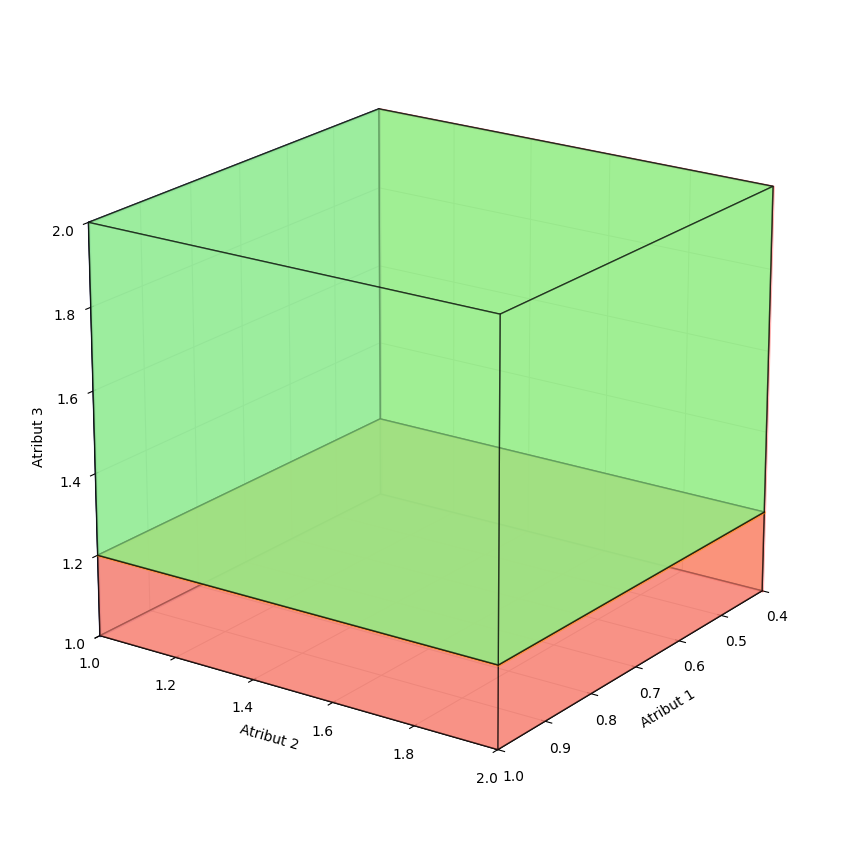

In [97]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define box vertices within the limits [0.4, 1] x [1, 2] x [1, 2]
# Bottom level (z=1)
vertices_bottom = np.array([
    [0.4, 1, 1],
    [1, 1, 1],
    [1, 2, 1],
    [0.4, 2, 1]
])

# Middle level (z=1.2) - where the cut plane is
vertices_middle = np.array([
    [0.4, 1, 1.2],
    [1, 1, 1.2],
    [1, 2, 1.2],
    [0.4, 2, 1.2]
])

# Top level (z=2)
vertices_top = np.array([
    [0.4, 1, 2],
    [1, 1, 2],
    [1, 2, 2],
    [0.4, 2, 2]
])

# Better definition of faces for lower region
faces_lower = [
    [vertices_bottom[1], vertices_bottom[2], vertices_middle[2], vertices_middle[1]],  # right face (x=1)
    [vertices_bottom[0], vertices_middle[0], vertices_middle[3], vertices_bottom[3]],  # left face (x=0.4)
    [vertices_bottom[2], vertices_bottom[3], vertices_middle[3], vertices_middle[2]],  # back face (y=2)
    [vertices_bottom[0], vertices_bottom[1], vertices_middle[1], vertices_middle[0]],  # front face (y=1)
    [vertices_bottom[0], vertices_bottom[1], vertices_bottom[2], vertices_bottom[3]],  # bottom (z=1)
    [vertices_middle[0], vertices_middle[1], vertices_middle[2], vertices_middle[3]]   # cut plane (z=1.2)
]

# Define the faces for the upper region (above z=1.2) in greenish color
faces_upper = [
    [vertices_middle[1], vertices_middle[2], vertices_top[2], vertices_top[1]],  # right face (x=1)
    [vertices_middle[0], vertices_top[0], vertices_top[3], vertices_middle[3]],  # left face (x=0.4)
    [vertices_middle[2], vertices_middle[3], vertices_top[3], vertices_top[2]],  # back face (y=2)
    [vertices_middle[0], vertices_middle[1], vertices_top[1], vertices_top[0]],  # front face (y=1)
    [vertices_middle[0], vertices_middle[1], vertices_middle[2], vertices_middle[3]],  # bottom of upper region (z=1.2)
    [vertices_top[0], vertices_top[1], vertices_top[2], vertices_top[3]]   # top (z=2)
]

# Create the 3D polygon collections
lower_collection = Poly3DCollection(faces_lower, alpha=0.6, facecolor='salmon', edgecolor='black', linewidth=1)
ax.add_collection3d(lower_collection)

upper_collection = Poly3DCollection(faces_upper, alpha=0.6, facecolor='lightgreen', edgecolor='black', linewidth=1)
ax.add_collection3d(upper_collection)

# Add plane at x = 0.4
plane_vertices_x = np.array([
    [0.4, 1, 1],
    [0.4, 2, 1],
    [0.4, 2, 2],
    [0.4, 1, 2]
])
plane_face_x = [plane_vertices_x]
plane_collection_x = Poly3DCollection(plane_face_x, alpha=0.3, facecolor='yellow', edgecolor='red', linewidth=2)
ax.add_collection3d(plane_collection_x)

# Add plane at y = 1
plane_vertices_y = np.array([
    [0.4, 1, 1],
    [1, 1, 1],
    [1, 1, 2],
    [0.4, 1, 2]
])
plane_face_y = [plane_vertices_y]
plane_collection_y = Poly3DCollection(plane_face_y, alpha=0.3, facecolor='lightblue', edgecolor='darkblue', linewidth=2)
ax.add_collection3d(plane_collection_y)

# Add plane at z = 1.2
plane_vertices_z = np.array([
    [0.4, 1, 1.2],
    [1, 1, 1.2],
    [1, 2, 1.2],
    [0.4, 2, 1.2]
])
plane_face_z = [plane_vertices_z]
plane_collection_z = Poly3DCollection(plane_face_z, alpha=0.5, facecolor='orange', edgecolor='darkorange', linewidth=2)
ax.add_collection3d(plane_collection_z)

# Set labels and limits
ax.set_xlabel('Atribut 1')
ax.set_ylabel('Atribut 2')
ax.set_zlabel('Atribut 3')
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)
ax.set_xlim([0.4, 1])
ax.set_ylim([1, 2])
ax.set_zlim([1, 2])
ax.view_init(azim=35, elev=20)

# Shift the 3D axes left to keep the z-label visible.
ax.set_box_aspect((1,1,0.9), zoom=0.95)
plt.tight_layout(pad=-1, w_pad=-1)

plt.savefig("primer_povrsine.pdf", dpi=300)

/tmp/ipykernel_7158/1234746265.py:18: FutureWarning: The provided callable <function mean at 0x7a5dedfeb880> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = df.groupby(["Features", "errRange", "n_samples"]).agg(agg_r).reset_index()


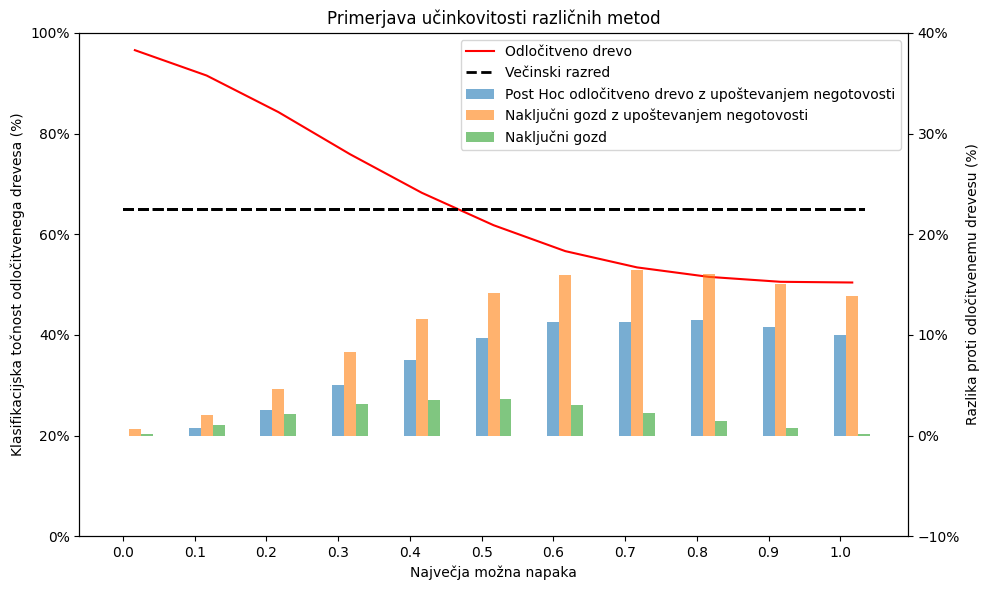

In [116]:
results = ["skl", "post_hoc", "uncertain_forest", "random_forest", "majority",]# "logistic_regression"]

# Legend relabeling (single place to control legend text)
legend_labels = {
    "skl": "Odločitveno drevo",
    "majority": "Večinski razred",
    "post_hoc": "Post Hoc odločitveno drevo z upoštevanjem negotovosti",
    "uncertain_forest": "Naključni gozd z upoštevanjem negotovosti",
    "random_forest": "Naključni gozd",
    "logistic_regression": "logistic_regression"
}

# Define aggregation dictionary dynamically based on the selected results
agg_r = {learner: [np.mean] for learner in results}

# Load and process the data
df = pd.read_csv("data/results2feat_50worlds_0.3endA_2-clases_0.9-correlation.csv")
df = df.groupby(["Features", "errRange", "n_samples"]).agg(agg_r).reset_index()

# Only display n_samples == 40
samples = 40
samples_data = df[df["n_samples"] == samples]

# Prepare data for plotting
x = samples_data["errRange"]
bar_learners = [learner for learner in results if learner not in ["majority", "skl"]]
bar_width = 0.05 / len(bar_learners)
bar_positions = {}
for j, learner in enumerate(bar_learners):
    bar_positions[learner] = x + j * bar_width

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()

ax.plot(
    [np.array(list(bar_positions.values()))[:, j].mean() for j in range(len(x))],
    samples_data[("skl", "mean")],
    color="red",
    label=legend_labels["skl"]
)

for learner in results:
    if learner == "majority":
        majority_means = samples_data[(learner, "mean")]
        continue
    if learner == "skl":
        continue

    means = samples_data[(learner, "mean")] - samples_data[("skl", "mean")]
    ax2.bar(
        bar_positions[learner],
        means,
        yerr=0,
        width=bar_width,
        label=legend_labels.get(learner, learner),
        alpha=0.6
    )

ax.hlines(
    y=majority_means,
    xmin=0,
    xmax=np.max(np.array(list(bar_positions.values()))),
    colors="k",
    linestyles="--",
    lw=2,
    label=legend_labels["majority"]
)

plt.xticks(x)
ax.set_xlabel("Največja možna napaka")
ax.set_ylabel(f"Klasifikacijska točnost odločitvenega drevesa (%)")
ax2.set_ylabel("Razlika proti odločitvenemu drevesu (%)")
ax.set_title("Primerjava učinkovitosti različnih metod")
ax.set_ylim([0, 1])
ax2.set_ylim([-0.1, 0.4])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

# Merge legends from both y-axes so line and bar labels are all visible.
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.savefig("primer_uporabe_graf.pdf", dpi=300)